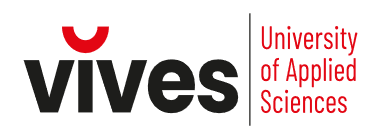<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **OUR FIRST NEURAL NETWORK IN KERAS**

We can also solve regression problems using artificial neural networks. In fact, the simple linear regression that we solved using Stochastic Gradient Descent is the simplest neural network we can construct. In this notebook, we demonstrate this by fitting our LinkedIn dataset using [Keras](https://keras.io/), a Python interface for Deep Learning that utilizes TensorFlow, Google Brain's Machine Learning library. In the Deep Learning course, we will explore neural networks in more depth and also use Keras there.

## The LinkedIn dataset

We read the "LinkedIn" dataset in as Pandas `Dataframe`:

In [1]:
import pandas as pd

linkedin = pd.read_csv("linkedIn.csv")
linkedin.head()

,loon,connecties
0,3252,304
1,2968,216
2,2976,159
3,3255,273
4,1953,191


The number of connections (`'connecties'` in Dutch) is the independent variable $x$, while the monthly salary (`'loon'` in Dutch) is the dependent variable $y$.

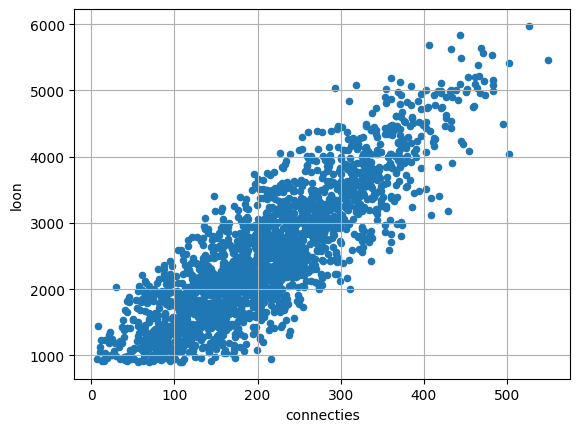

In [2]:
linkedin.plot.scatter (x="connecties", y="loon", grid=True);

First, we will scale both variables by dividing them by their respective maximum:

In [4]:
x = linkedin.connecties.values / linkedin.connecties.max()
y = linkedin.loon.values / linkedin.loon.max()

Keras models expect 2D arrays as input: the rows are the examples or samples, the columns are the features or variables.

In [5]:
import numpy as np

X = x[:, np.newaxis]  # x is a 1D vector -> X is a 2D matrix with 1 column only
Y = y[:, np.newaxis]  # y is a 1D vector -> Y is a 2D matrix with 1 column only

## Defining a Keras model

For linear regression we need a neural network with only one neuron. In Keras we define a `Sequential` model with 1 `Dense` layer that contains 1 node or `unit`:

In [14]:
from tensorflow import keras
from keras import Sequential, layers

model = Sequential()              # Sequential is a class that we must instantiate
model.add(layers.Dense(units=1))  # using method add() we add a Dense layer with 1 unit

## Compiling the Keras model

During the compilation of the model, we specify the optimizer, which is used to minimize the loss function. Here, we use Stochastic Gradient Descent (SGD) with a learning rate of 0.01. We also need to specify the loss function; in this case, we use the Mean Squared Error (MSE).

In [15]:
sgd = keras.optimizers.SGD(learning_rate=0.01)  # SGD is also a class that we have to instantiate
model.compile(optimizer=sgd, loss="MSE")        # MSE is the loss function to be minimized by SGD

## Training the Keras model

Just like in Scikit-Learn, in Keras, you need to call the model's `fit` method to train it. The first two arguments are, of course, the features `X` and the target `Y`. We also specify the batch size, which we set to 1 here, meaning that the data points will be processed one by one. Additionally, we define the number of epochs. The `fit` method returns a `History` object, which contains, among other things, the values of the loss function after each epoch.

In [16]:
history = model.fit(X, Y, batch_size=1, epochs=20);

Epoch 1/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - loss: 0.0612
Epoch 2/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 972us/step - loss: 0.0116
Epoch 3/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0081
Epoch 4/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 5s 990us/step - loss: 0.0073
Epoch 5/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0075
Epoch 6/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 985us/step - loss: 0.0074
Epoch 7/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0074
Epoch 8/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0076
Epoch 9/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 999us/step - loss: 0.0073
Epoch 10/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0075  
Epoch 11/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0075
Epoch 12/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0072
Epoch 13/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 2s 982us/step - loss: 0.0078
Epoch 14/20
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0076
Epoch 15/20
206

Let's plot the loss as a function of the number of epochs:

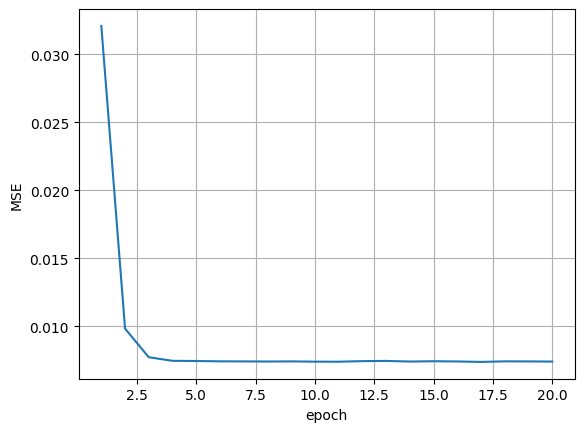

In [18]:
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss);
plt.xlabel('epoch');
plt.ylabel('MSE');
plt.grid();

We can see that the loss function has not improved after a certain number of epochs. In principle, we should also use a validation set to check whether the model suffers from overfitting. Additionally, after training, we should evaluate the model on a test set. The process of splitting the dataset and its benefits will be covered later in the course.

In a neural network, the parameters are also called weights. We can find them in the `weights` attribute of our `model` object. In this case, the first weight is the slope, and the second weight is the intercept, which is referred to as the "bias" here. The exact meaning of this will be discussed in detail later in the course. The weights are stored as TensorFlow variables. Using the `numpy` method, we can convert them into NumPy arrays.

In [21]:
slope = model.weights[0].numpy()[0][0]
intercept = model.weights[1].numpy()[0]
print(slope, intercept)

0.81504935 0.10007802


Let's plot the regression line using the derived values for `slope` and `intercept`. We must not forget to convert the regression line back to the original units!

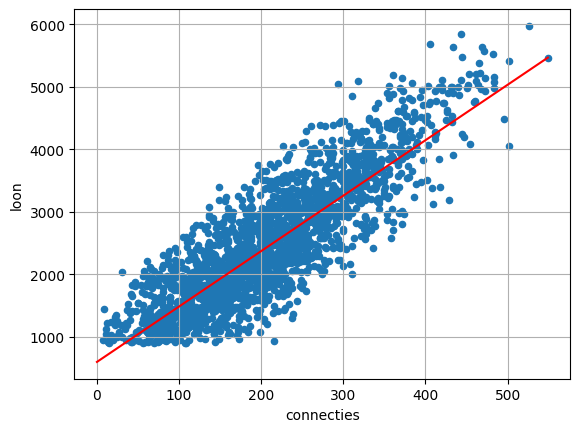

In [20]:
# scatterplot
linkedin.plot.scatter(x="connecties", y="loon", grid=True);

# regression line
x_line = np.array([0, 1])  # variable x is scaled to numbers between 0 and 1!
y_line = slope * x_line + intercept  # y = ax + b
plt.plot(x_line * linkedin.connecties.max(), y_line * linkedin.loon.max(), 'r');  # don't forget to scale back!

## Making predictions

Just like in Scikit-Learn, the `Sequential` object has a method `predict` with which we can make predictions for new data. Suppose we want to predict how much someone earns with 252 LinkedIn connections, then we do this as follows:

In [27]:
x_new = 252 / linkedin.connecties.max()             # don't forget to scale!
y_pred = model.predict(np.array([[x_new]])).item()  # here too we work with 2D arrays ...
y_pred * linkedin.loon.max()                        # don't forget to scale back!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


2832.864986240864

So we must not forget that we have scaled the data! We will explore this scaling in more detail later in the course. For now, remember that it is usually a good idea to normalize the input of a neural network in some way.

---
---

## Source

"Deep Learning with Python" (2nd Edition) by François Chollet (2021)

---